#  Phân Tích Cảm Xúc Người Dùng (Sentiment Analysis) cho Tiếng Việt

##  Mục tiêu
Xây dựng hệ thống học sâu (Deep Learning) để phân loại cảm xúc đa lớp từ bình luận tiếng Việt:
- Happiness (Vui vẻ, hài lòng)
- Disgust (Khó chịu, ghê tởm)
- Surprise (Ngạc nhiên)
- Sadness (Buồn bã)
- Anger (Tức giận)
- Fear (Sợ hãi)

##  Phương pháp tiếp cận (Deep Learning)
1. Khám phá dữ liệu (EDA)
2. Tiền xử lý (chuẩn hoá tencode + làm sạch + loại bỏ stopwords)
3. Biểu diễn văn bản bằng Tokenizer + Padding (Keras)
4. Huấn luyện nhiều mô hình học sâu:
   - MLP (Keras) với đặc trưng chuỗi (Embedding + Pooling)
   - 1D CNN
   - BiLSTM
   - CNN + BiLSTM (hybrid)
5. Đánh giá, so sánh, trực quan hóa kết quả
6. Lưu mô hình Keras + Tokenizer để triển khai

In [1]:
# Cài đặt lại scikit-learn để sửa lỗi xung đột
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.6 MB/s eta 0:00:00


In [2]:
#  Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thư viện xử lý văn bản
import re
import string
from collections import Counter
import random

# Thư viện machine learning (đánh giá & tiền xử lý)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import AdamW  # Cải tiến: Sử dụng AdamW cho optimizer ổn định hơn

# Transformers cho PhoBERT (phiên bản 4.30.2+)
try:
    from transformers import AutoTokenizer, TFAutoModel
    from transformers import logging as transformers_logging
    transformers_logging.set_verbosity_error()
    print(" Import transformers thành công!")
except ImportError as e:
    print(f" Lỗi import transformers: {e}")
    print(" Hãy chạy: pip install transformers==4.30.2 tensorflow==2.12.0 keras==2.12.0 --force-reinstall")

# Set style for plots
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')  # Fallback cho phiên bản cũ
sns.set_palette("husl")

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Kiểm tra phiên bản và compatibility
print("  KIỂM TRA PHIÊN BẢN THỬ VIỆN")
print("=" * 50)
print(f" Pandas version: {pd.__version__}")
print(f" TensorFlow version: {tf.__version__}")
print(f" NumPy version: {np.__version__}")
print(f" Seaborn version: {sns.__version__}")
print(f" Matplotlib version: {plt.matplotlib.__version__}")

2026-02-03 14:57:52.990173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770130673.192940      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770130673.251685      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770130673.757062      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770130673.757107      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770130673.757110      25 computation_placer.cc:177] computation placer alr

 Import transformers thành công!
  KIỂM TRA PHIÊN BẢN THỬ VIỆN
 Pandas version: 2.2.2
 TensorFlow version: 2.19.0
 NumPy version: 2.0.2
 Seaborn version: 0.13.2
 Matplotlib version: 3.10.0


In [3]:
# Kiểm tra và kích hoạt GPU trên Kaggle
print("\nKIỂM TRA GPU")
print("=" * 50)
physical_devices = tf.config.list_physical_devices('GPU')
print("Số lượng GPU có sẵn: ", len(physical_devices))
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.set_visible_devices(physical_devices[0], 'GPU')
        print("GPU đã được thiết lập thành công.")
    except RuntimeError as e:
        print(e)
else:
    print("Không tìm thấy GPU. Chạy trên CPU.")

# Tùy chọn: Bật mixed precision để tăng tốc trên GPU (nếu có)
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')
print("Mixed precision đã được kích hoạt để tăng tốc huấn luyện trên GPU.")


KIỂM TRA GPU
Số lượng GPU có sẵn:  1
GPU đã được thiết lập thành công.
Mixed precision đã được kích hoạt để tăng tốc huấn luyện trên GPU.


In [4]:
# Kiểm tra transformers version nếu import thành công
try:
    import transformers
    print(f" Transformers version: {transformers.__version__}")

    # Kiểm tra compatibility
    tf_major = int(tf.__version__.split('.')[0])
    tf_minor = int(tf.__version__.split('.')[1])

    if tf_major == 2 and tf_minor >= 12:
        print(" TensorFlow version tương thích")
    else:
        print("  TensorFlow version có thể không tương thích hoàn toàn")

except ImportError:
    print(" Transformers: Chưa được cài đặt")

 Transformers version: 4.57.1
 TensorFlow version tương thích


##  1. Khám Phá Dữ Liệu (Exploratory Data Analysis)

In [5]:
#  Đọc dữ liệu
data_path = "/kaggle/input/data-tiki-for-sentiment/datadl.csv"
df = pd.read_csv(data_path)

print(" THÔNG TIN CƠ BẢN VỀ DỮ LIỆU")
print("=" * 50)
print(f" Kích thước dữ liệu: {df.shape}")
print(f" Số lượng mẫu: {len(df):,}")
print(f" Các cột: {list(df.columns)}")
print(f" Giá trị thiếu: {df.isnull().sum().sum()}")

# Hiển thị thông tin chi tiết
print("\n THÔNG TIN CHI TIẾT")
print("=" * 50)
df.info()

print("\n MẪU DỮ LIỆU ĐẦU TIÊN")
print("=" * 50)
display(df.head())

 THÔNG TIN CƠ BẢN VỀ DỮ LIỆU
 Kích thước dữ liệu: (26382, 2)
 Số lượng mẫu: 26,382
 Các cột: ['content', 'lable']
 Giá trị thiếu: 0

 THÔNG TIN CHI TIẾT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26382 entries, 0 to 26381
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  26382 non-null  object
 1   lable    26382 non-null  object
dtypes: object(2)
memory usage: 412.3+ KB

 MẪU DỮ LIỆU ĐẦU TIÊN


,content,lable
0,Tôi sử dụng rất ít mà đã hỏng không vào điện.\...,surprise
1,"Mình bị mất dây sạc, mua xong 2 năm rồi ko dùn...",disgust
2,"Tôi quên ko bỏ dây nạp vào hộp dề trả lại, tôi...",surprise
3,"Máy dùng sau gần 1 năm có vấn đề về pin, được ...",happiness
4,Khi mơi dùng tia nước khá mạnh và sạch kẽ răng...,disgust


In [6]:
#  Phân tích phân phối các lớp cảm xúc
print(" PHÂN TÍCH PHÂN PHỐI CÁC LỚP CẢM XÚC")
print("=" * 50)

# Đếm số lượng mỗi lớp
emotion_counts = df['lable'].value_counts()
emotion_props = df['lable'].value_counts(normalize=True) * 100

print(" Số lượng và tỷ lệ từng lớp cảm xúc:")
for emotion, count in emotion_counts.items():
    prop = emotion_props[emotion]
    print(f"  {emotion:10s}: {count:5,} mẫu ({prop:5.1f}%)")

print(f"\n Tổng số lớp cảm xúc: {len(emotion_counts)}")
print(f" Lớp ít nhất: {emotion_counts.min():,} mẫu")
print(f" Lớp nhiều nhất: {emotion_counts.max():,} mẫu")
print(f" Tỷ lệ mất cân bằng: {emotion_counts.max() / emotion_counts.min():.1f}:1")

 PHÂN TÍCH PHÂN PHỐI CÁC LỚP CẢM XÚC
 Số lượng và tỷ lệ từng lớp cảm xúc:
  surprise  : 4,784 mẫu ( 18.1%)
  happiness : 4,784 mẫu ( 18.1%)
  anger     : 4,784 mẫu ( 18.1%)
  sadness   : 4,784 mẫu ( 18.1%)
  fear      : 4,484 mẫu ( 17.0%)
  disgust   : 2,762 mẫu ( 10.5%)

 Tổng số lớp cảm xúc: 6
 Lớp ít nhất: 2,762 mẫu
 Lớp nhiều nhất: 4,784 mẫu
 Tỷ lệ mất cân bằng: 1.7:1


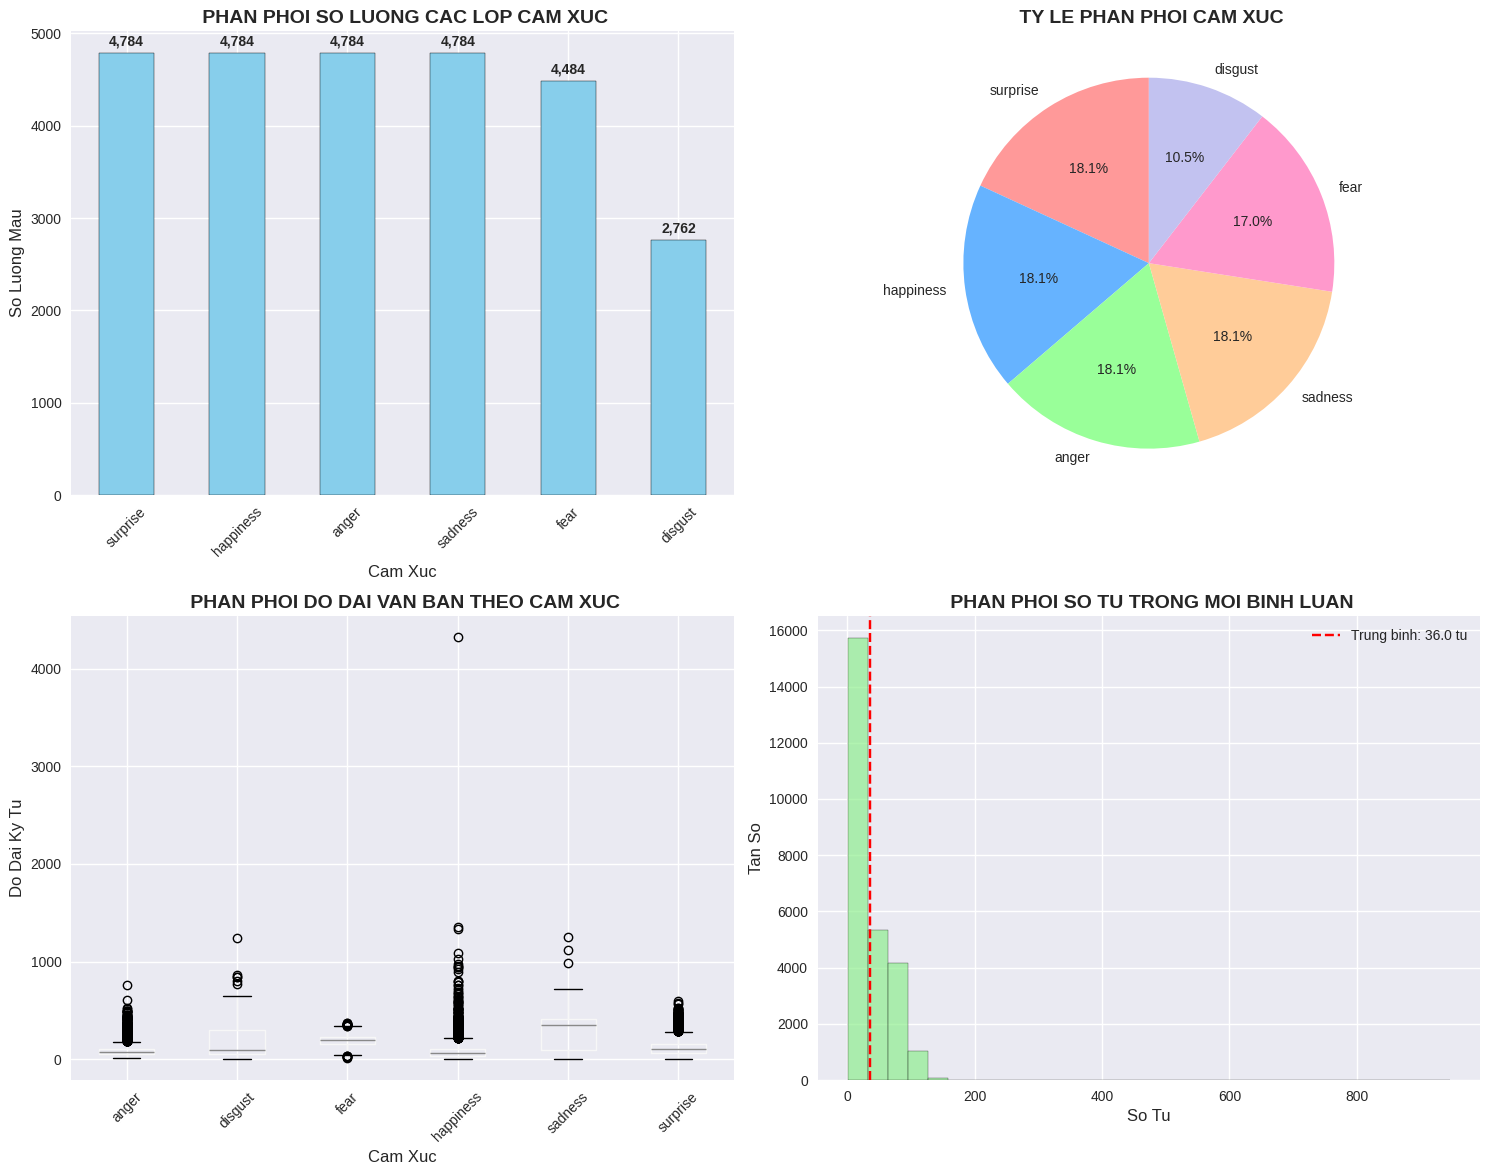


 THONG KE DO DAI VAN BAN
Do dai trung binh: 160.1 ky tu
So tu trung binh: 36.0 tu
Do dai ngan nhat: 1 ky tu
Do dai dai nhat: 4323 ky tu


In [7]:
import matplotlib.pyplot as plt

# Trực quan hóa phân phối dữ liệu
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Biểu đồ cột
emotion_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title(' PHAN PHOI SO LUONG CAC LOP CAM XUC', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cam Xuc', fontsize=12)
ax1.set_ylabel('So Luong Mau', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(emotion_counts.values):
    ax1.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# 2. Biểu đồ tròn
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']
emotion_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title(' TY LE PHAN PHOI CAM XUC', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

# 3. Phân tích độ dài văn bản
# Đảm bảo cột text_length và word_count đã được tạo
df['text_length'] = df['content'].astype(str).str.len()
df['word_count'] = df['content'].astype(str).str.split().str.len()

# Boxplot cho độ dài văn bản theo cảm xúc
df.boxplot(column='text_length', by='lable', ax=ax3)
ax3.set_title(' PHAN PHOI DO DAI VAN BAN THEO CAM XUC', fontsize=14, fontweight='bold')
ax3.set_xlabel('Cam Xuc', fontsize=12)
ax3.set_ylabel('Do Dai Ky Tu', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
# Xóa tiêu đề phụ tự động sinh ra bởi pandas để đỡ rối
plt.suptitle('')

# 4. Histogram số từ
ax4.hist(df['word_count'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax4.set_title(' PHAN PHOI SO TU TRONG MOI BINH LUAN', fontsize=14, fontweight='bold')
ax4.set_xlabel('So Tu', fontsize=12)
ax4.set_ylabel('Tan So', fontsize=12)
ax4.axvline(df['word_count'].mean(), color='red', linestyle='--',
            label=f'Trung binh: {df["word_count"].mean():.1f} tu')
ax4.legend()

plt.tight_layout()
plt.show()

# In thống kê về độ dài văn bản
print("\n THONG KE DO DAI VAN BAN")
print("=" * 50)
print(f"Do dai trung binh: {df['text_length'].mean():.1f} ky tu")
print(f"So tu trung binh: {df['word_count'].mean():.1f} tu")
print(f"Do dai ngan nhat: {df['text_length'].min()} ky tu")
print(f"Do dai dai nhat: {df['text_length'].max()} ky tu")

##  2. Tiền Xử Lý Dữ Liệu (Text Preprocessing)

**Các bước tiền xử lý cho tiếng Việt:**
- Chuẩn hóa teencode trong văn bản
- Làm sạch văn bản (loại bỏ ký tự đặc biệt, emoji, URL)
- Chuẩn hóa văn bản (chữ thường, bỏ dấu câu thừa)
- Tokenization và lemmatization
- Loại bỏ stop words tiếng Việt

In [8]:
import time
# 1. TẢI TỪ ĐIỂN (TÊN GỐC - LOGIC TỐI ƯU LỌC NHIỄU)
def load_teencode_dict():
    """Đọc file teencode.txt và tạo từ điển thay thế (đã lọc nhiễu)"""
    teencode_dict = {}
    # Danh sách đen: Những từ viết tắt 1-2 ký tự dễ gây hiểu nhầm nếu thay tự động
    # Ví dụ: 'c' -> 'chị', 'ng' -> 'người', 'k' -> 'không' (nếu dính trong từ khác)
    blacklist = {'c', 'k', 'n', 'ng', 'a', 'e', 'h', 'o', 'dc', 'x', 't', 'b'}

    try:
        with open('/kaggle/working/teencode.txt', 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 2:
                    key, value = parts
                    key = key.strip().lower() # Chuyển về chữ thường để đồng bộ

                    # Logic an toàn: Bỏ qua blacklist và các từ quá ngắn nếu không chắc chắn
                    if key in blacklist or (len(key) < 2 and key.isalpha()):
                        continue

                    teencode_dict[key] = value.strip()

        print(f" Da tai va toi uu: {len(teencode_dict)} cap tu teencode")
    except FileNotFoundError:
        print(" Khong tim thay file teencode.txt")
    except Exception as e:
        print(f" Loi khi doc file: {e}")

    return teencode_dict


# 2. HÀM CHUẨN HÓA (TÊN GỐC - LOGIC TÁCH TỪ TOKENIZE)
def normalize_teencode(text, teencode_dict):
    """
    Chuẩn hóa teencode: Nhanh hơn và chính xác hơn nhờ tách từ (Tokenization)
    """
    if not isinstance(text, str) or not text:
        return ""

    # Bước 1: Tách văn bản thành danh sách [từ, dấu, từ, dấu...]
    # re.split giữ lại cả dấu câu để khi ghép lại không bị mất format
    tokens = re.split(r'(\W+)', text)

    # Bước 2: Tra từ điển (Hash map lookup - O(1))
    # Chỉ thay thế nếu từ đó (viết thường) nằm trong từ điển
    normalized_tokens = [
        teencode_dict.get(token.lower(), token)
        for token in tokens
    ]

    # Bước 3: Ghép lại thành chuỗi
    return "".join(normalized_tokens)


In [9]:
# Tải từ điển
teencode_dict = load_teencode_dict()

print("\n DANG CHUAN HOA TOAN BO DATASET...")
print("-" * 60)
start_time = time.time()

# Áp dụng lên toàn bộ cột 'content'
# Kết quả lưu vào cột mới 'content_normalized'
df['content_normalized'] = df['content'].apply(lambda x: normalize_teencode(x, teencode_dict))

end_time = time.time()
duration = end_time - start_time

# --- Thống kê kết quả ---
total_rows = len(df)
changed_rows = df[df['content'] != df['content_normalized']].shape[0]

print(f" Da xu ly xong {total_rows:,} dong.")
print(f" Thoi gian chay : {duration:.2f} giay")
print(f" So dong thay doi: {changed_rows:,} ({changed_rows/total_rows*100:.1f}%)")
print("-" * 60)

# Xem thử 3 mẫu thay đổi để kiểm tra
print(" MOT SO MAU DA THAY DOI:")
changed_samples = df[df['content'] != df['content_normalized']]
if not changed_samples.empty:
    changed_samples = changed_samples.sample(n=min(3, len(changed_samples)))
    for idx, row in changed_samples.iterrows():
        print(f"Goc:      {row['content']}")
        print(f"Sau khi sua: {row['content_normalized']}")
        print("-" * 30)

 Khong tim thay file teencode.txt

 DANG CHUAN HOA TOAN BO DATASET...
------------------------------------------------------------
 Da xu ly xong 26,382 dong.
 Thoi gian chay : 0.66 giay
 So dong thay doi: 0 (0.0%)
------------------------------------------------------------
 MOT SO MAU DA THAY DOI:


In [10]:
# Hàm tiền xử lý văn bản tiếng Việt
import unicodedata
from underthesea import word_tokenize  # Import underthesea cho tokenization tiếng Việt

def clean_text(text):
    """
    Hàm làm sạch văn bản tiếng Việt
    """
    if pd.isna(text):
        return ""

    # Chuyển về string nếu cần
    text = str(text)

    # Loại bỏ URL
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # Loại bỏ email
    text = re.sub(r'\S+@\S+', '', text)

    # Loại bỏ số điện thoại
    text = re.sub(r'[\+]?[1-9]?[0-9]{7,15}', '', text)

    # Thay thế số bằng token 'number_token' TRƯỚC khi lọc ký tự đặc biệt
    # (Tránh dùng <NUMBER> vì dấu < > sẽ bị regex bên dưới xóa mất)
    text = re.sub(r'\d+', ' number_token ', text)

    # Giữ lại chữ cái tiếng Việt, khoảng trắng và dấu gạch dưới (cho từ ghép nếu có)
    text = re.sub(r'[^\w\s\u00C0-\u1EF9_]', ' ', text)

    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text)

    # Chuyển về chữ thường
    text = text.lower()

    # Loại bỏ khoảng trắng đầu cuối
    text = text.strip()

    return text

# Stop words tiếng Việt cơ bản
vietnamese_stopwords = set([
    'tôi', 'mình', 'tao', 'mày', 'họ', 'nó', 'chúng', 'ta', 'chúng_tôi', 'chúng_ta',
    'bạn', 'anh', 'chị', 'em', 'cô', 'chú', 'bác', 'ông', 'bà',
    'và', 'với', 'của', 'trong', 'tại', 'ở', 'trên', 'dưới', 'cho', 'về',
    'là', 'có', 'được', 'bị', 'phải', 'đã', 'đang', 'sẽ', 'vẫn', 'còn',
    'như', 'nhưng', 'thì', 'mà', 'nếu', 'vì', 'do', 'nên',
    'rất', 'quá', 'lắm', 'cực', 'hơi', 'khá',
    'cái', 'chiếc', 'những', 'các', 'mọi', 'này', 'kia', 'đó',
    'ạ', 'nhé', 'à', 'ừ', 'vâng', 'dạ', 'thôi', 'rồi', 'nhỉ',
    'shop', 'tiki', 'shopee', 'lazada', 'sản_phẩm', 'mua', 'bán'
])

def remove_stopwords(text):
    """
    Loại bỏ stop words tiếng Việt, sử dụng underthesea để tách từ đúng cách
    """
    # Sử dụng word_tokenize để tách từ ghép đúng (ví dụ: "học sinh" thành một token)
    words = word_tokenize(text)

    # Lọc stopword và giữ lại từ > 1 ký tự
    filtered_words = [word for word in words if word not in vietnamese_stopwords and len(word) > 1]

    # Thay thế khoảng trắng trong từ ghép bằng dấu gạch dưới (_) để giữ ngữ nghĩa từ ghép
    # VD: "sinh viên" -> "sinh_viên". Đây là bước quan trọng cho Deep Learning
    filtered_words = [word.replace(' ', '_') for word in filtered_words]

    return ' '.join(filtered_words)

# Áp dụng tiền xử lý
print(" Đang thực hiện tiền xử lý văn bản...")
print("=" * 50)

# Tạo bản sao dữ liệu
df_processed = df.copy()

# Hiển thị mẫu trước khi xử lý
print(" MẪU VĂN BẢN TRƯỚC KHI XỬ LÝ:")
sample_text = df['content'].iloc[0]
print(f"Gốc: {sample_text}")

# Chain với content_normalized
df_processed['content_cleaned'] = df_processed['content_normalized'].apply(clean_text)

# Loại bỏ stop words (bây giờ dùng underthesea)
df_processed['content_final'] = df_processed['content_cleaned'].apply(remove_stopwords)

# Hiển thị mẫu sau khi xử lý
print(f"\nSau khi làm sạch: {df_processed['content_cleaned'].iloc[0]}")
print(f"Sau khi loại bỏ stop words: {df_processed['content_final'].iloc[0]}")

# Loại bỏ các mẫu có văn bản quá ngắn (dựa trên số từ, min 2 từ)
min_words = 2
df_processed = df_processed[df_processed['content_final'].str.split().str.len() >= min_words]

print(f"\n Số lượng mẫu sau khi lọc: {len(df_processed):,}")
print(f" Số lượng mẫu bị loại bỏ: {len(df) - len(df_processed):,}")

# Hiển thị một vài mẫu sau xử lý
print(f"\n MỘT VÀI MẪU SAU KHI XỬ LÝ:")
print("=" * 50)
for i in range(3):
    print(f"{i+1}. Label: {df_processed['lable'].iloc[i]}")
    print(f"   Text: {df_processed['content_final'].iloc[i][:100]}...")
    print()

 Đang thực hiện tiền xử lý văn bản...
 MẪU VĂN BẢN TRƯỚC KHI XỬ LÝ:
Gốc: Tôi sử dụng rất ít mà đã hỏng không vào điện.
Tôi có được bảo hành không? 
Nếu được bảo hành tôi gửi theo đc nào? Hãy hướng dẫn

Sau khi làm sạch: tôi sử dụng rất ít mà đã hỏng không vào điện tôi có được bảo hành không nếu được bảo hành tôi gửi theo đc nào hãy hướng dẫn
Sau khi loại bỏ stop words: sử_dụng ít hỏng không vào điện bảo_hành không bảo_hành gửi theo đc nào hãy hướng_dẫn

 Số lượng mẫu sau khi lọc: 26,176
 Số lượng mẫu bị loại bỏ: 206

 MỘT VÀI MẪU SAU KHI XỬ LÝ:
1. Label: surprise
   Text: sử_dụng ít hỏng không vào điện bảo_hành không bảo_hành gửi theo đc nào hãy hướng_dẫn...

2. Label: disgust
   Text: mất dây_sạc xong number_token năm ko dùng cửa_hàng xử_lý giúp...

3. Label: surprise
   Text: quên ko bỏ dây_nạp vào hộp dề trả lại có_thể chuyển trả cửa_hàng bằng cách nào...



In [11]:
# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


use_augmentation = True      # bật / tắt text augmentation nhẹ
augmentation_ratio = 0.2     # Cải tiến: Tăng tỷ lệ augmentation lên 20% để chống overfit và học sâu hơn
vocab_size = 20000
oov_token = "<OOV>"
max_len = 100
max_len_phobert = 256
batch_size = 128             # Cải tiến: Tăng batch_size lên 128 để học nhanh hơn, ổn định gradient
epochs = 20
embedding_dim = 128
phobert_model_name = "vinai/phobert-base"

In [12]:
# 1. CHUẨN BỊ DỮ LIỆU CHUNG (GHÉP VÀ CHIA 1 LẦN)
# ============================================================
print(" CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH")
print("=" * 50)

# Encode labels
label_encoder = LabelEncoder()
df_processed['label_encoded'] = label_encoder.fit_transform(df_processed['lable'])  # SỬ DỤNG 'lable'

# In mapping của labels
print(" MAPPING CÁC LỚP CẢM XÚC:")
for i, label in enumerate(label_encoder.classes_):
    count = (df_processed['label_encoded'] == i).sum()
    print(f"  {i}: {label} ({count:,} mẫu)")

# Chia dữ liệu train/test (CHỈ CHIA 1 LẦN)
X = df_processed['content_final'].values
y = df_processed['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\n CHIA DỮ LIỆU:")
print(f"  Training set: {len(X_train):,} mẫu")
print(f"  Test set: {len(X_test):,} mẫu")
print(f"  Số lớp: {len(label_encoder.classes_)}")

# Hiển thị phân phối trong tập train
train_distribution = pd.Series(y_train).value_counts().sort_index()
print(f"\n PHÂN PHỐI TẬP TRAIN:")
for i, count in enumerate(train_distribution):
    label = label_encoder.classes_[i]
    print(f"  {label}: {count:,} mẫu ({count/len(y_train)*100:.1f}%)")

# Cải tiến: Tính class weights để xử lý imbalance, giúp ổn định và học sâu hơn
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print(f"\n Class weights: {class_weights_dict}")

 CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH
 MAPPING CÁC LỚP CẢM XÚC:
  0: anger (4,779 mẫu)
  1: disgust (2,757 mẫu)
  2: fear (4,484 mẫu)
  3: happiness (4,647 mẫu)
  4: sadness (4,782 mẫu)
  5: surprise (4,727 mẫu)

 CHIA DỮ LIỆU:
  Training set: 20,940 mẫu
  Test set: 5,236 mẫu
  Số lớp: 6

 PHÂN PHỐI TẬP TRAIN:
  anger: 3,823 mẫu (18.3%)
  disgust: 2,206 mẫu (10.5%)
  fear: 3,587 mẫu (17.1%)
  happiness: 3,718 mẫu (17.8%)
  sadness: 3,825 mẫu (18.3%)
  surprise: 3,781 mẫu (18.1%)

 Class weights: {0: np.float64(0.9128956317028512), 1: np.float64(1.5820489573889394), 2: np.float64(0.9729579035405631), 3: np.float64(0.9386767079074771), 4: np.float64(0.9124183006535947), 5: np.float64(0.9230362338005819)}


In [13]:
# 2. TEXT AUGMENTATION NHẸ (OPTIONAL)
# - Rất nhẹ: random deletion / random swap
# - Không cần thư viện ngoài
# ============================================================
def random_deletion(words, p=0.15):  # Cải tiến: Tăng p để augmentation mạnh hơn chống overfit
    if len(words) == 1:
        return words
    new_words = []
    for w in words:
        if random.uniform(0,1) > p:
            new_words.append(w)
    if len(new_words) == 0:
        return [random.choice(words)]
    return new_words

def random_swap(words, n_swaps=2):  # Cải tiến: Tăng n_swaps để đa dạng dữ liệu
    words = words.copy()
    for _ in range(n_swaps):
        i = random.randint(0, len(words)-1)
        j = random.randint(0, len(words)-1)
        words[i], words[j] = words[j], words[i]
    return words

def augment_text(text):
    tokens = text.split()
    if len(tokens) < 2:
        return text
    choice = random.choice(['del', 'swap'])
    if choice == 'del':
        new_tokens = random_deletion(tokens, p=0.15)
    else:
        new_tokens = random_swap(tokens, n_swaps=2)
    return " ".join(new_tokens)

# Tạo dữ liệu augmented (góp thêm một phần nhỏ vào tập train)
if use_augmentation:
    n_aug = int(len(X_train) * augmentation_ratio)
    idxs = np.random.choice(len(X_train), n_aug, replace=False)
    X_aug_texts = [augment_text(X_train[i]) for i in idxs]
    y_aug = y_train[idxs]
    # Gộp lại
    X_train_aug = np.concatenate([X_train, np.array(X_aug_texts)], axis=0)
    y_train_aug = np.concatenate([y_train, y_aug], axis=0)
    print(f"Augmentation: thêm {n_aug} mẫu -> Train tổng: {len(X_train_aug)}")
else:
    X_train_aug = X_train
    y_train_aug = y_train

Augmentation: thêm 4188 mẫu -> Train tổng: 25128


In [14]:
# 3. KERAS TOKENIZER + PAD (CHO CNN/LSTM/MLP/HYBRID)
# ============================================================
print("\n CHUẨN BỊ DỮ LIỆU CHO DEEP LEARNING (Tokenizer + Padding)")
print("=" * 70)

# Mặc định Keras Tokenizer sẽ lọc bỏ '_' — ta sửa filters để giữ '_'
custom_filters = '!"#$%&()*+,-./:;<=>?@[\\]^`{|}~\t\n'  # không chứa '_'

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token, filters=custom_filters)
# fit trên tập train (đã augmented nếu bật)
tokenizer.fit_on_texts(X_train_aug)

# Chuyển văn bản thành chuỗi số
X_train_seq = tokenizer.texts_to_sequences(X_train_aug)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

num_classes = len(label_encoder.classes_)
print(f" Số lớp: {num_classes}")
print(f" Vocab size thực tế: {min(vocab_size, len(tokenizer.word_index)+1):,}")
print(f" Kích thước X_train_pad: {X_train_pad.shape}, X_test_pad: {X_test_pad.shape}")


 CHUẨN BỊ DỮ LIỆU CHO DEEP LEARNING (Tokenizer + Padding)
 Số lớp: 6
 Vocab size thực tế: 9,474
 Kích thước X_train_pad: (25128, 100), X_test_pad: (5236, 100)


##  3. Xây Dựng Các Mô Hình Học Sâu

Trong phần này, chúng ta xây dựng và so sánh các mô hình học sâu cho phân tích cảm xúc tiếng Việt:
1. MLP (Keras) với Embedding + Pooling
2. 1D CNN
3. BiLSTM
4. CNN + BiLSTM (hybrid)
5. PhoBERT (BERT pre-trained cho tiếng Việt)

Các mô hình được huấn luyện trên dữ liệu đã token hóa và pad độ dài (Keras Tokenizer).

In [15]:
print("\n HUẤN LUYỆN CÁC MÔ HÌNH DEEP LEARNING")
print("=" * 60)

def compile_and_train(model, X_tr, y_tr, X_va, y_va, name):
    # Cải tiến: Sử dụng AdamW cho optimizer ổn định hơn, weight decay chống overfit
    model.compile(optimizer=AdamW(learning_rate=5e-4, weight_decay=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  # Cải tiến: Tăng patience để ổn định
    rlrop = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)  # Cải tiến: Factor nhỏ hơn để giảm LR mạnh
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[es, rlrop],
        verbose=2,
        class_weight=class_weights_dict  # Cải tiến: Thêm class_weight để xử lý imbalance, ổn định học
    )
    print(f"\n{name} - Done. Best val_acc: {max(history.history['val_accuracy']):.4f}")
    return history

# Hàm vẽ confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()


 HUẤN LUYỆN CÁC MÔ HÌNH DEEP LEARNING


### 3.1 Mô hình 1: 1D CNN

In [16]:
print("\n[M1] CNN - Building & Training")
tf.keras.backend.clear_session()  # Xóa session để tránh memory leak trên GPU
cnn_model = models.Sequential([
    layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim,
                     input_length=max_len),
    layers.SpatialDropout1D(0.3),  # Cải tiến: Tăng dropout để chống overfit

    layers.Conv1D(128, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),  # Cải tiến: Thêm kernel nhỏ hơn, tăng filters để học sâu
    layers.BatchNormalization(),  # Cải tiến: Thêm BatchNorm để ổn định, học nhanh
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 3, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),  # Cải tiến: Thêm layer Conv để học sâu hơn
    layers.BatchNormalization(),
    layers.GlobalMaxPooling1D(),

    layers.Dropout(0.5),  # Cải tiến: Tăng dropout
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),  # Cải tiến: Tăng units để học sâu
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax', dtype='float32')  # Chỉnh dtype cho mixed precision
])

cnn_model.build(input_shape=(None, max_len))
cnn_model.summary()


[M1] CNN - Building & Training


I0000 00:00:1770130741.396560      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,054 (5.07 MB)

 Trainable params: 1,329,286 (5.07 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20


I0000 00:00:1770130745.548888      77 service.cc:152] XLA service 0x7a606c005350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770130745.548926      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770130746.126131      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770130751.181772      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


197/197 - 14s - 72ms/step - accuracy: 0.4347 - loss: 1.6974 - val_accuracy: 0.3214 - val_loss: 2.2763 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 1s - 6ms/step - accuracy: 0.8135 - loss: 0.6251 - val_accuracy: 0.4303 - val_loss: 1.4739 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 1s - 6ms/step - accuracy: 0.8927 - loss: 0.3988 - val_accuracy: 0.9131 - val_loss: 0.3839 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 1s - 6ms/step - accuracy: 0.9179 - loss: 0.3133 - val_accuracy: 0.9286 - val_loss: 0.2627 - learning_rate: 5.0000e-04
Epoch 5/20
197/197 - 1s - 6ms/step - accuracy: 0.9342 - loss: 0.2590 - val_accuracy: 0.9312 - val_loss: 0.2573 - learning_rate: 5.0000e-04
Epoch 6/20
197/197 - 1s - 6ms/step - accuracy: 0.9462 - loss: 0.2196 - val_accuracy: 0.9318 - val_loss: 0.2560 - learning_rate: 5.0000e-04
Epoch 7/20
197/197 - 1s - 6ms/step - accuracy: 0.9532 - loss: 0.1897 - val_accuracy: 0.9312 - val_loss: 0.2647 - learning_rate: 5.0000e-04
Epoch 8/20

Epoch 8: ReduceLROnPlate

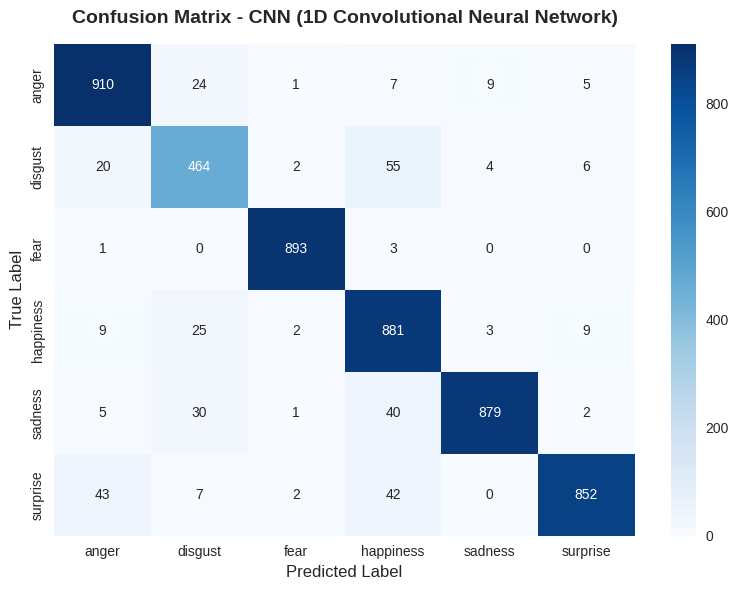

In [17]:
hist_cnn = compile_and_train(cnn_model, X_train_pad, y_train_aug, X_test_pad, y_test, name='CNN')

y_pred_cnn_prob = cnn_model.predict(X_test_pad)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
report_cnn = classification_report(y_test, y_pred_cnn, target_names=label_encoder.classes_, output_dict=True)
print(f" Accuracy: {cnn_accuracy:.4f}")
print(classification_report(y_test, y_pred_cnn, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_cnn, 'CNN (1D Convolutional Neural Network)', label_encoder.classes_)


### 3.2 Mô hình 2: BiLSTM

In [18]:
print("\n[M2] BiLSTM - Building & Training")
tf.keras.backend.clear_session()  # Xóa session để tránh memory leak trên GPU
bilstm_model = models.Sequential([
    layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim,
                     input_length=max_len),
    layers.SpatialDropout1D(0.3),  # Cải tiến: Tăng dropout

    layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.4, recurrent_dropout=0.4)),  # Cải tiến: Tăng units, dropout để học sâu và chống overfit
    layers.BatchNormalization(),  # Cải tiến: Thêm BatchNorm
    layers.Bidirectional(layers.LSTM(128, return_sequences=False, dropout=0.4, recurrent_dropout=0.4)),  # Cải tiến: Thêm layer LSTM thứ 2 để học sâu hơn
    layers.BatchNormalization(),

    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax', dtype='float32')  # Chỉnh dtype cho mixed precision
])

bilstm_model.build(input_shape=(None, max_len))
bilstm_model.summary()


[M2] BiLSTM - Building & Training


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,906,310 (7.27 MB)

 Trainable params: 1,905,030 (7.27 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/20
197/197 - 187s - 949ms/step - accuracy: 0.4977 - loss: 1.5430 - val_accuracy: 0.4039 - val_loss: 1.5215 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 170s - 865ms/step - accuracy: 0.8558 - loss: 0.4876 - val_accuracy: 0.9106 - val_loss: 0.4051 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 170s - 862ms/step - accuracy: 0.9082 - loss: 0.3327 - val_accuracy: 0.9299 - val_loss: 0.2502 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 169s - 859ms/step - accuracy: 0.9295 - loss: 0.2630 - val_accuracy: 0.9316 - val_loss: 0.2582 - learning_rate: 5.0000e-04
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 167s - 849ms/step - accuracy: 0.9405 - loss: 0.2260 - val_accuracy: 0.9335 - val_loss: 0.2690 - learning_rate: 5.0000e-04
Epoch 6/20
197/197 - 167s - 847ms/step - accuracy: 0.9503 - loss: 0.1872 - val_accuracy: 0.9326 - val_loss: 0.2640 - learning_rate: 1.5000e-04
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 

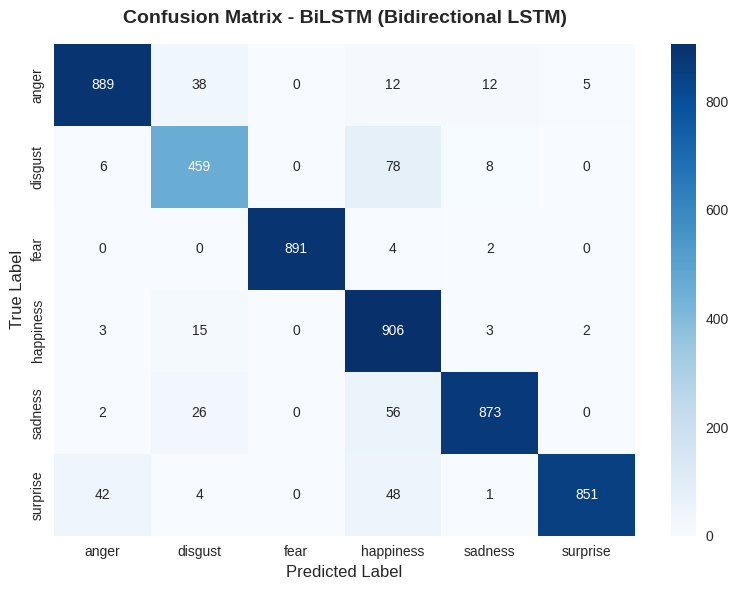

In [19]:
hist_bilstm = compile_and_train(bilstm_model, X_train_pad, y_train_aug, X_test_pad, y_test, name='BiLSTM')

y_pred_bilstm_prob = bilstm_model.predict(X_test_pad)
y_pred_bilstm = np.argmax(y_pred_bilstm_prob, axis=1)
bilstm_accuracy = accuracy_score(y_test, y_pred_bilstm)
report_bilstm = classification_report(y_test, y_pred_bilstm, target_names=label_encoder.classes_, output_dict=True)
print(f" Accuracy: {bilstm_accuracy:.4f}")
print(classification_report(y_test, y_pred_bilstm, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_bilstm, 'BiLSTM (Bidirectional LSTM)', label_encoder.classes_)


### 3.3. Mô hình 3: CNN + BiLSTM (hybrid)

In [20]:
print("\n[M3] CNN + BiLSTM - Building & Training")
tf.keras.backend.clear_session()  # Xóa session để tránh memory leak trên GPU
input_layer = layers.Input(shape=(max_len,))
x = layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim,
                     input_length=max_len)(input_layer)

x = layers.SpatialDropout1D(0.3)(x)  # Cải tiến: Tăng dropout
x = layers.Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)  # Cải tiến: Kernel nhỏ, tăng filters
x = layers.BatchNormalization()(x)  # Cải tiến: Thêm BatchNorm
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)  # Cải tiến: Thêm Conv layer
x = layers.BatchNormalization()(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.4, recurrent_dropout=0.4))(x)  # Cải tiến: Tăng units, dropout
x = layers.BatchNormalization()(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output_layer = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)  # Chỉnh dtype cho mixed precision
hybrid_model = models.Model(inputs=input_layer, outputs=output_layer)

hybrid_model.summary()


[M3] CNN + BiLSTM - Building & Training


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,610,630 (6.14 MB)

 Trainable params: 1,609,350 (6.14 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/20
197/197 - 55s - 280ms/step - accuracy: 0.3280 - loss: 2.0398 - val_accuracy: 0.1774 - val_loss: 2.6051 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 47s - 240ms/step - accuracy: 0.7421 - loss: 0.8581 - val_accuracy: 0.5151 - val_loss: 1.4381 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 80s - 408ms/step - accuracy: 0.8869 - loss: 0.4361 - val_accuracy: 0.9246 - val_loss: 0.3246 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 45s - 228ms/step - accuracy: 0.9214 - loss: 0.3225 - val_accuracy: 0.9309 - val_loss: 0.2900 - learning_rate: 5.0000e-04
Epoch 5/20
197/197 - 45s - 228ms/step - accuracy: 0.9390 - loss: 0.2504 - val_accuracy: 0.9330 - val_loss: 0.2980 - learning_rate: 5.0000e-04
Epoch 6/20

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 45s - 231ms/step - accuracy: 0.9512 - loss: 0.2102 - val_accuracy: 0.9343 - val_loss: 0.3021 - learning_rate: 5.0000e-04
Epoch 7/20
197/197 - 45s - 228ms/step - accuracy: 0.9622 - loss: 0.1738

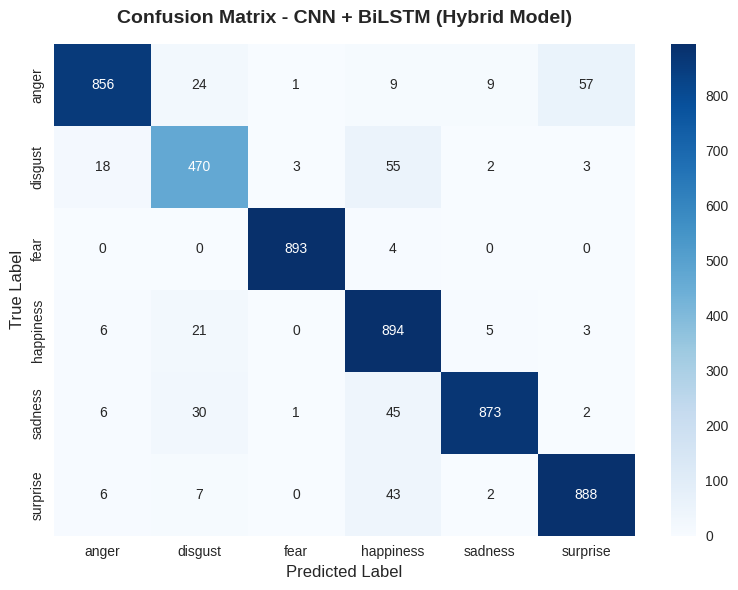

In [21]:
hist_hybrid = compile_and_train(hybrid_model, X_train_pad, y_train_aug, X_test_pad, y_test, name='CNN+BiLSTM')
y_pred_hybrid_prob = hybrid_model.predict(X_test_pad)
y_pred_hybrid = np.argmax(y_pred_hybrid_prob, axis=1)
hybrid_accuracy = accuracy_score(y_test, y_pred_hybrid)
report_hybrid = classification_report(y_test, y_pred_hybrid, target_names=label_encoder.classes_, output_dict=True)
print(f" Accuracy: {hybrid_accuracy:.4f}")
print(classification_report(y_test, y_pred_hybrid, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_hybrid, 'CNN + BiLSTM (Hybrid Model)', label_encoder.classes_)


### 3.4   Mô hình 4: MLP (Keras) đơn giản trên chuỗi (Embedding + Pooling)

In [22]:
print("\n[M4] MLP - Building & Training")
tf.keras.backend.clear_session()  # Xóa session để tránh memory leak trên GPU
nn_model = models.Sequential([
    layers.Embedding(input_dim=min(vocab_size, len(tokenizer.word_index)+1),
                     output_dim=embedding_dim,
                     input_length=max_len),
    layers.GlobalAveragePooling1D(),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),  # Cải tiến: Tăng units để học sâu
    layers.BatchNormalization(),  # Cải tiến: Thêm BatchNorm
    layers.Dropout(0.5),  # Cải tiến: Tăng dropout
    layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),  # Cải tiến: Thêm layer Dense để học sâu hơn
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax', dtype='float32')  # Chỉnh dtype cho mixed precision
])

nn_model.build(input_shape=(None, max_len))
nn_model.summary()



[M4] MLP - Building & Training


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,212,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,902 (4.89 MB)

 Trainable params: 1,280,134 (4.88 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20
197/197 - 8s - 39ms/step - accuracy: 0.7684 - loss: 0.7713 - val_accuracy: 0.4005 - val_loss: 1.7249 - learning_rate: 5.0000e-04
Epoch 2/20
197/197 - 1s - 4ms/step - accuracy: 0.9277 - loss: 0.2800 - val_accuracy: 0.6163 - val_loss: 1.1694 - learning_rate: 5.0000e-04
Epoch 3/20
197/197 - 1s - 4ms/step - accuracy: 0.9481 - loss: 0.2018 - val_accuracy: 0.8021 - val_loss: 0.5634 - learning_rate: 5.0000e-04
Epoch 4/20
197/197 - 1s - 4ms/step - accuracy: 0.9591 - loss: 0.1586 - val_accuracy: 0.9043 - val_loss: 0.3848 - learning_rate: 5.0000e-04
Epoch 5/20
197/197 - 1s - 4ms/step - accuracy: 0.9661 - loss: 0.1364 - val_accuracy: 0.9148 - val_loss: 0.4272 - learning_rate: 5.0000e-04
Epoch 6/20

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
197/197 - 1s - 4ms/step - accuracy: 0.9731 - loss: 0.1153 - val_accuracy: 0.8913 - val_loss: 0.4973 - learning_rate: 5.0000e-04
Epoch 7/20
197/197 - 1s - 4ms/step - accuracy: 0.9786 - loss: 0.0922 - val_accuracy: 0.9

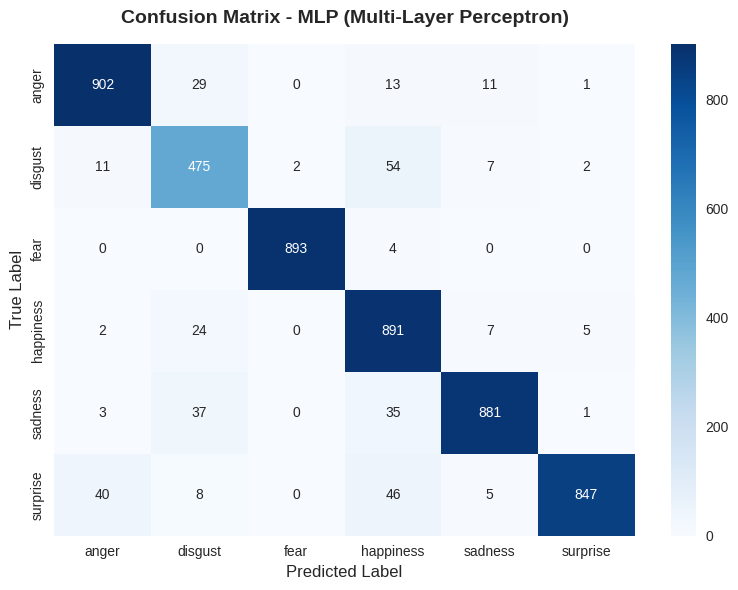

In [23]:
hist_mlp = compile_and_train(nn_model, X_train_pad, y_train_aug, X_test_pad, y_test, name='MLP')

y_pred_nn_prob = nn_model.predict(X_test_pad)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)
nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f" Accuracy: {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)")
report_nn = classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_, output_dict=True)
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))
plot_confusion_matrix(y_test, y_pred_nn, 'MLP (Multi-Layer Perceptron)', label_encoder.classes_)


 BIỂU ĐỒ QUÁ TRÌNH HUẤN LUYỆN 


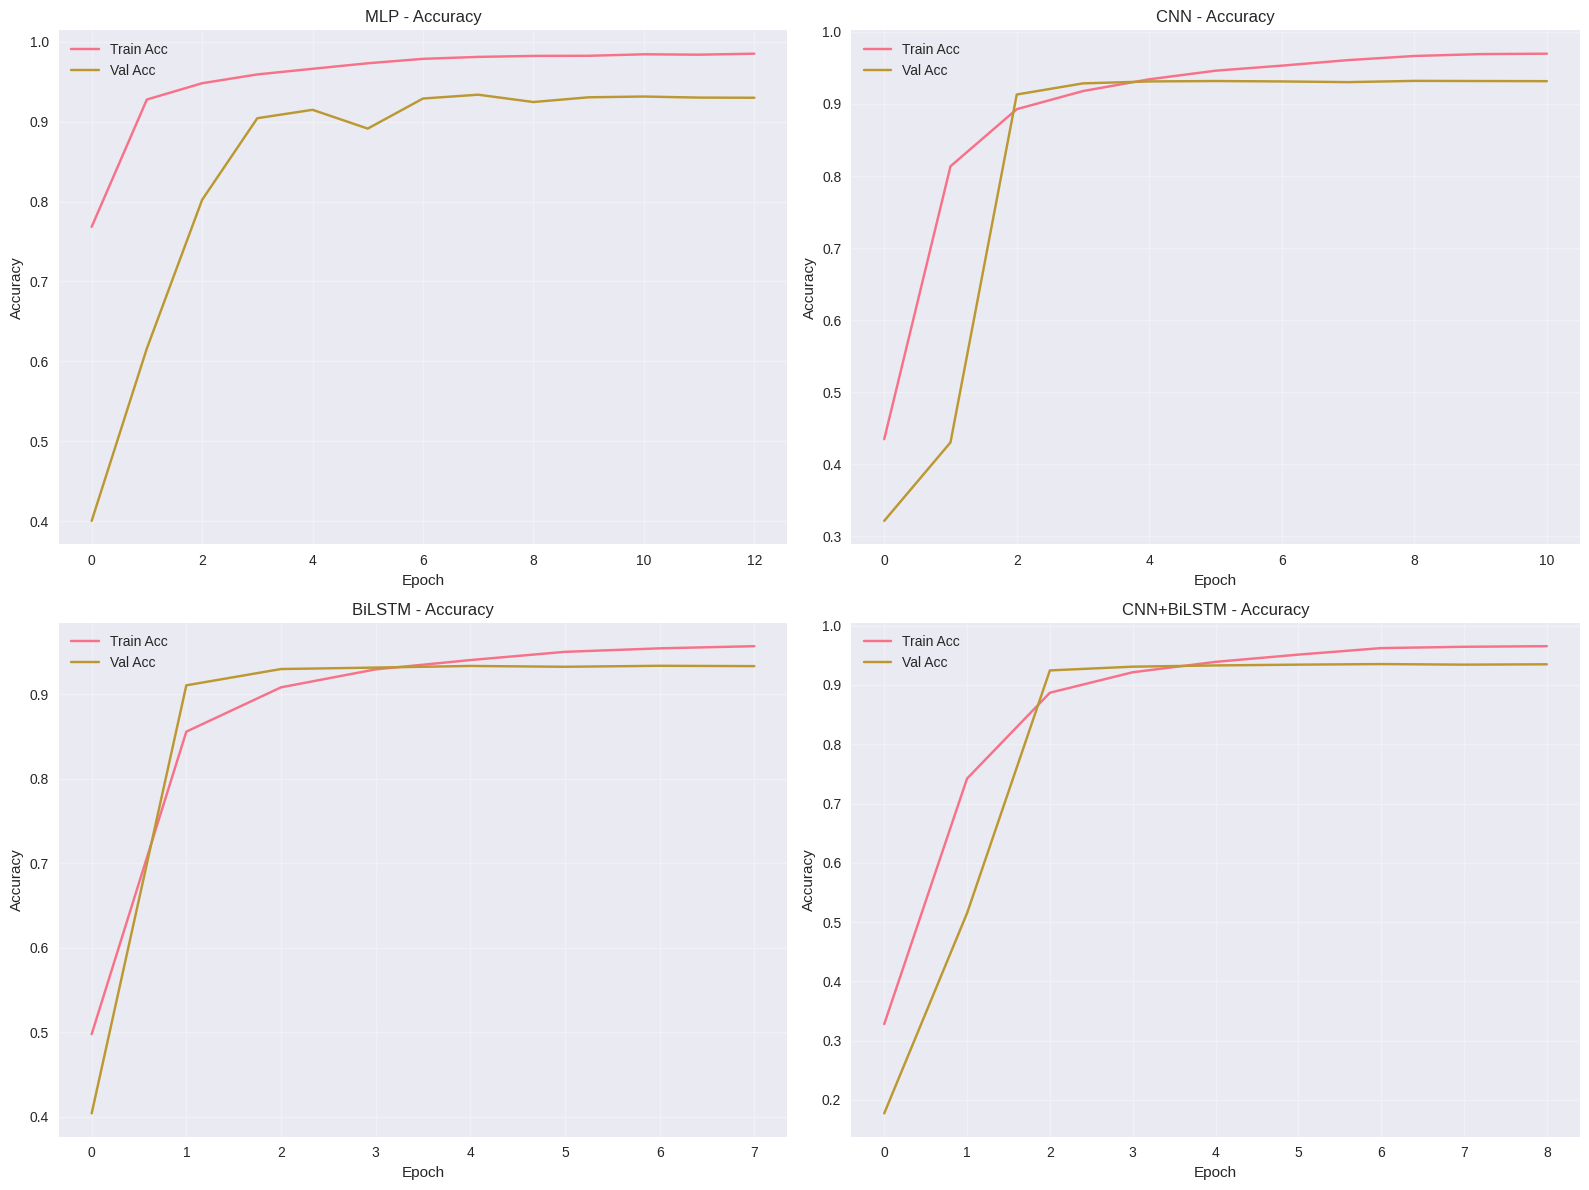

In [24]:
print(" BIỂU ĐỒ QUÁ TRÌNH HUẤN LUYỆN ")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. MLP ---
ax = axes[0, 0]
ax.plot(hist_mlp.history['accuracy'], label='Train Acc')
ax.plot(hist_mlp.history['val_accuracy'], label='Val Acc')
ax.set_title('MLP - Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 2. CNN ---
ax = axes[0, 1]
ax.plot(hist_cnn.history['accuracy'], label='Train Acc')
ax.plot(hist_cnn.history['val_accuracy'], label='Val Acc')
ax.set_title('CNN - Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 3. BiLSTM ---
ax = axes[1, 0]
ax.plot(hist_bilstm.history['accuracy'], label='Train Acc')
ax.plot(hist_bilstm.history['val_accuracy'], label='Val Acc')
ax.set_title('BiLSTM - Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- 4. CNN + BiLSTM ---
ax = axes[1, 1]
ax.plot(hist_hybrid.history['accuracy'], label='Train Acc')
ax.plot(hist_hybrid.history['val_accuracy'], label='Val Acc')
ax.set_title('CNN+BiLSTM - Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##  4. So Sánh Hiệu Suất Các Mô Hình

 SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH DEEP LEARNING
               Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Neural Network (MLP)    0.9337             0.9299          0.9294            0.9286
                 CNN    0.9318             0.9283          0.9262            0.9264
              BiLSTM    0.9299             0.9290          0.9239            0.9248
          CNN+BiLSTM    0.9309             0.9281          0.9262            0.9262

 MÔ HÌNH TỐT NHẤT: Neural Network (MLP)
 Accuracy: 0.9337 (93.37%)


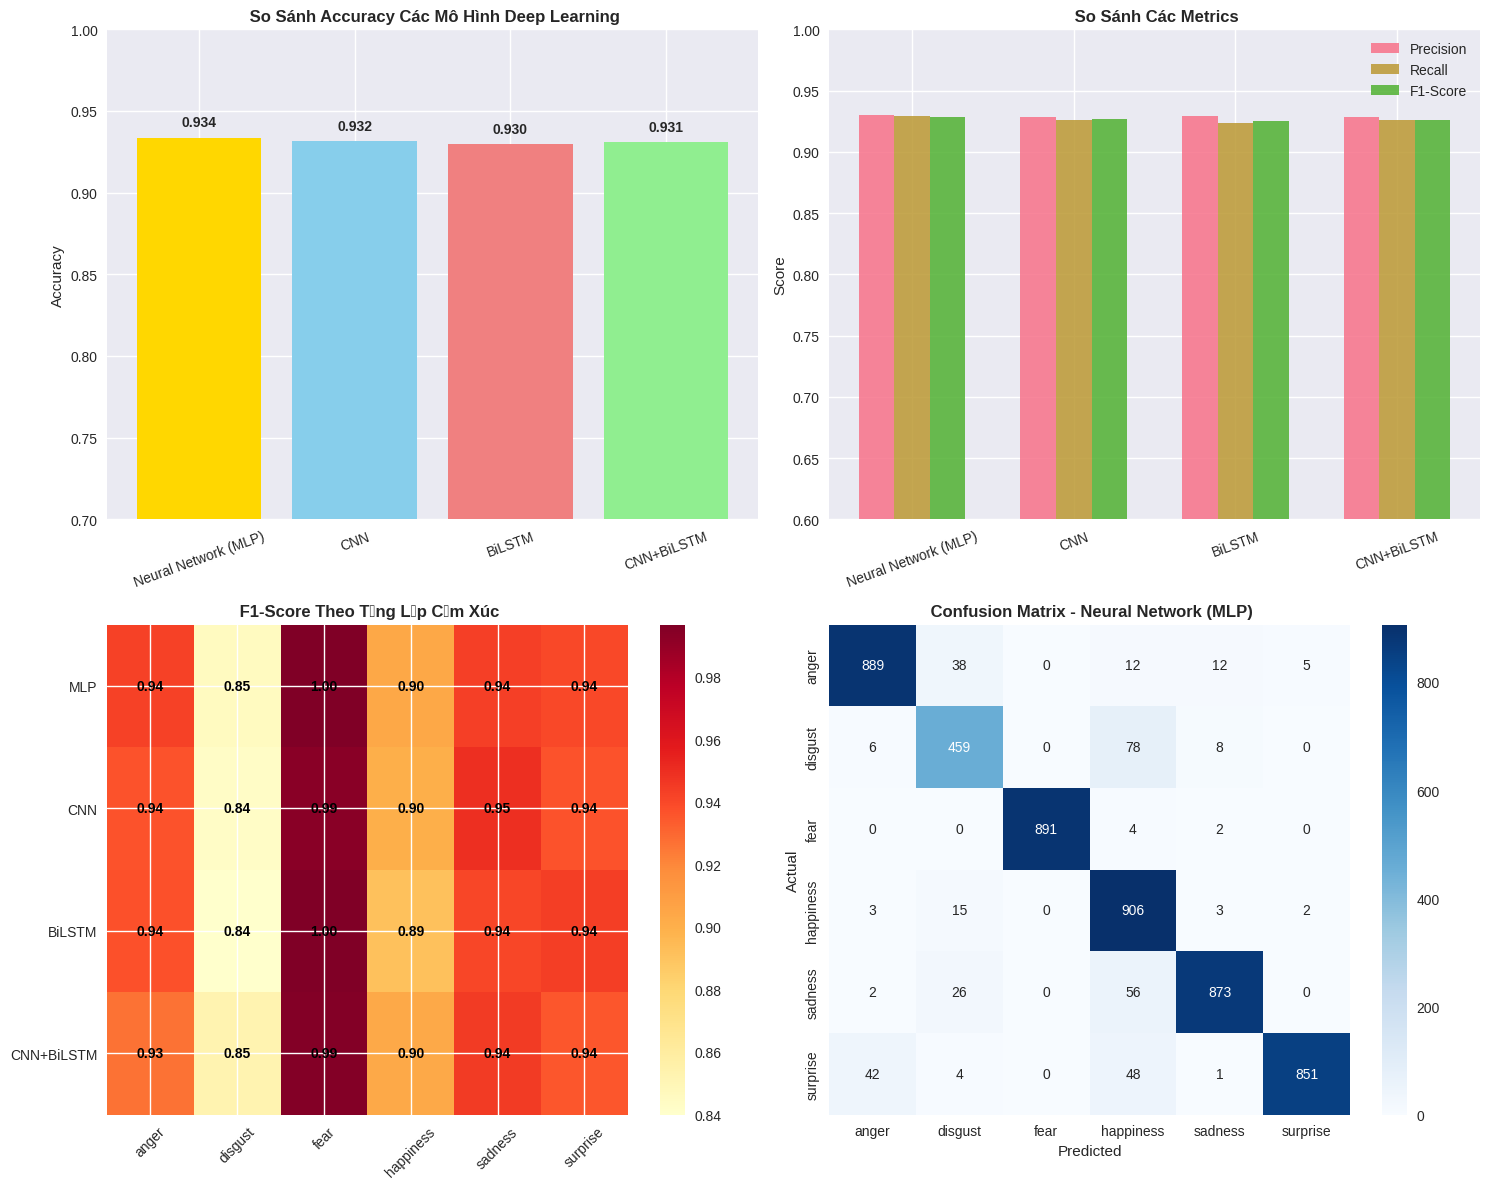

  - Best model: Neural Network (MLP) | Accuracy: 0.9337
  - Best model: Neural Network (MLP) | Accuracy: 0.9337

 THỐNG KÊ TÓM TẮT CUỐI CÙNG:
  - Best model: Neural Network (MLP) | Accuracy: 0.9337


In [25]:
#  So sánh hiệu suất các mô hình Deep Learning

print(" SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH DEEP LEARNING")
print("=" * 60)

models_comparison = {
    'Model': ['Neural Network (MLP)', 'CNN', 'BiLSTM', 'CNN+BiLSTM'],
    'Accuracy': [nn_accuracy, cnn_accuracy, bilstm_accuracy, hybrid_accuracy],
    'Precision (macro)': [
        report_nn['macro avg']['precision'],
        report_cnn['macro avg']['precision'],
        report_bilstm['macro avg']['precision'],
        report_hybrid['macro avg']['precision']
    ],
    'Recall (macro)': [
        report_nn['macro avg']['recall'],
        report_cnn['macro avg']['recall'],
        report_bilstm['macro avg']['recall'],
        report_hybrid['macro avg']['recall']

    ],
    'F1-Score (macro)': [
        report_nn['macro avg']['f1-score'],
        report_cnn['macro avg']['f1-score'],
        report_bilstm['macro avg']['f1-score'],
        report_hybrid['macro avg']['f1-score']

    ]
}

comparison_df = pd.DataFrame(models_comparison).round(4)
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.iloc[best_model_idx]['Model']
best_accuracy = comparison_df.iloc[best_model_idx]['Accuracy']
print(f"\n MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f" Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Vẽ biểu đồ so sánh
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. So sánh Accuracy
ax1.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['gold', 'skyblue', 'lightcoral', 'lightgreen', 'orange'])
ax1.set_title(' So Sánh Accuracy Các Mô Hình Deep Learning', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.7, 1.0)
for i, v in enumerate(comparison_df['Accuracy']):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)

# 2. So sánh các metrics
metrics = ['Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
x = np.arange(len(comparison_df['Model']))
width = 0.22
for i, metric in enumerate(metrics):
    ax2.bar(x + i*width, comparison_df[metric], width, label=metric.split(' (')[0], alpha=0.85)
ax2.set_title(' So Sánh Các Metrics', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xticks(x + width)
ax2.set_xticklabels(comparison_df['Model'], rotation=20)
ax2.legend()
ax2.set_ylim(0.6, 1.0)

# 3. Heatmap hiệu suất theo từng lớp cảm xúc
models_results = {
    'MLP': report_nn,
    'CNN': report_cnn,
    'BiLSTM': report_bilstm,
    'CNN+BiLSTM': report_hybrid

}
f1_matrix = []
emotions = label_encoder.classes_
for model_name in models_results.keys():
    f1_scores = [models_results[model_name][emotion]['f1-score'] for emotion in emotions]
    f1_matrix.append(f1_scores)
f1_matrix = np.array(f1_matrix)
im = ax3.imshow(f1_matrix, cmap='YlOrRd', aspect='auto')
ax3.set_title(' F1-Score Theo Từng Lớp Cảm Xúc', fontweight='bold')
ax3.set_xticks(range(len(emotions)))
ax3.set_xticklabels(emotions, rotation=45)
ax3.set_yticks(range(len(models_results)))
ax3.set_yticklabels(models_results.keys())
for i in range(len(models_results)):
    for j in range(len(emotions)):
        ax3.text(j, i, f'{f1_matrix[i, j]:.2f}', ha="center", va="center", color="black", fontweight='bold')
plt.colorbar(im, ax=ax3)

# 4. Phân tích lỗi - Confusion Matrix của mô hình tốt nhất
if best_model_name.startswith('Neural Network'):
    y_pred_best = y_pred_nn
    y_pred_best = y_pred_bilstm
else:
    y_pred_best = y_pred_hybrid

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, xticklabels=emotions, yticklabels=emotions)
ax4.set_title(f' Confusion Matrix - {best_model_name}', fontweight='bold')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("=" * 50)
print(f"  - Best model: {best_model_name} | Accuracy: {best_accuracy:.4f}")
print("=" * 50)
print(f"  - Best model: {best_model_name} | Accuracy: {best_accuracy:.4f}")
print("\n THỐNG KÊ TÓM TẮT CUỐI CÙNG:")
print(f"  - Best model: {best_model_name} | Accuracy: {best_accuracy:.4f}")


##  5. Phân Tích Chi Tiết và Đánh Giá NLP

In [26]:
#  Phân tích lỗi chi tiết cho mô hình tốt nhất
print(f" PHÂN TÍCH LỖI CHI TIẾT - {best_model_name}")
print("=" * 60)

# Xác định y_pred_best và probabilities theo mô hình
if best_model_name.startswith('Neural Network'):
    y_pred_best = y_pred_nn
    prob_best = y_pred_nn_prob
elif best_model_name == 'CNN':
    y_pred_best = y_pred_cnn
    prob_best = y_pred_cnn_prob
elif best_model_name == 'BiLSTM':
    y_pred_best = y_pred_bilstm
    prob_best = y_pred_bilstm_prob
else:
    y_pred_best = y_pred_hybrid
    prob_best = y_pred_hybrid_prob

# Tạo DataFrame với kết quả dự đoán
results_df = pd.DataFrame({
    'text': X_test,
    'true_label': [label_encoder.classes_[i] for i in y_test],
    'predicted_label': [label_encoder.classes_[i] for i in y_pred_best],
    'correct': y_test == y_pred_best
})

# Phân tích lỗi theo từng lớp
print(" TỶ LỆ DỰ ĐOÁN ĐÚNG THEO TỪNG LỚP:")
for emotion in label_encoder.classes_:
    emotion_mask = results_df['true_label'] == emotion
    correct_rate = results_df[emotion_mask]['correct'].mean()
    total_samples = emotion_mask.sum()
    correct_samples = results_df[emotion_mask]['correct'].sum()
    print(f"  {emotion:10s}: {correct_samples:3d}/{total_samples:3d} ({correct_rate*100:5.1f}%)")

# Phân tích confusion matrix chi tiết
print(f"\n PHÂN TÍCH CONFUSION MATRIX:")
print("=" * 40)
cm = confusion_matrix(y_test, y_pred_best)
for i, true_emotion in enumerate(label_encoder.classes_):
    for j, pred_emotion in enumerate(label_encoder.classes_):
        if i != j and cm[i, j] > 0:
            error_rate = cm[i, j] / cm[i].sum() * 100
            if error_rate > 5:
                print(f"  {true_emotion} → {pred_emotion}: {cm[i,j]} mẫu ({error_rate:.1f}%)")

# Hiển thị một số mẫu bị phân loại sai
print(f"\n MỘT SỐ MẪU BỊ PHÂN LOẠI SAI:")
print("=" * 50)
wrong_predictions = results_df[~results_df['correct']].head(5)
for idx, row in wrong_predictions.iterrows():
    print(f" Text: {row['text'][:80]}...")
    print(f"   True: {row['true_label']} | Predicted: {row['predicted_label']}")
    print()

# Nếu có xác suất, phân tích độ tin cậy
if prob_best is not None:
    max_conf = prob_best.max(axis=1)
    print(f"\n PHÂN TÍCH ĐỘ TIN CẬY:")
    print(f"   Confidence trung bình: {np.mean(max_conf):.4f}")
    print(f"   Độ lệch chuẩn: {np.std(max_conf):.4f}")
    low_confidence_idx = np.argsort(max_conf)[:5]
    print(f"\n CÁC DỰ ĐOÁN ÍT TIN CẬY NHẤT:")
    for i, idx in enumerate(low_confidence_idx):
        true_label = label_encoder.classes_[y_test[idx]]
        pred_label = label_encoder.classes_[y_pred_best[idx]]
        confidence = max_conf[idx]
        text = X_test[idx][:60]
        print(f"   {i+1}. Confidence: {confidence:.3f}")
        print(f"      Text: {text}...")
        print(f"      True: {true_label} | Pred: {pred_label}")
        print()

# Tính class-wise performance dùng mô hình tốt nhất
print(f"\n HIỆU SUẤT THEO TỪNG LỚP (Best Model):")
print("=" * 50)
class_report = classification_report(y_test, y_pred_best, target_names=label_encoder.classes_, output_dict=True)
for emotion in label_encoder.classes_:
    metrics = class_report[emotion]
    support = int(metrics['support'])
    print(f"{emotion:10s}: P={metrics['precision']:.3f} | R={metrics['recall']:.3f} | F1={metrics['f1-score']:.3f} | Support={support:3d}")

 PHÂN TÍCH LỖI CHI TIẾT - Neural Network (MLP)
 TỶ LỆ DỰ ĐOÁN ĐÚNG THEO TỪNG LỚP:
  anger     : 902/956 ( 94.4%)
  disgust   : 475/551 ( 86.2%)
  fear      : 893/897 ( 99.6%)
  happiness : 891/929 ( 95.9%)
  sadness   : 881/957 ( 92.1%)
  surprise  : 847/946 ( 89.5%)

 PHÂN TÍCH CONFUSION MATRIX:
  disgust → happiness: 54 mẫu (9.8%)

 MỘT SỐ MẪU BỊ PHÂN LOẠI SAI:
 Text: tooooooooooooot tooooooooooooot toooooooooooot tooooooooooooot...
   True: surprise | Predicted: happiness

 Text: đặt number_token_quyển cả number_token_quyển đều ko nguyện_vẹn number_token sao...
   True: sadness | Predicted: disgust

 Text: mở hàng ra nắp_vỡ thế_này đổi ko ko_thể vận_chuyển...
   True: sadness | Predicted: disgust

 Text: không model nào khả_dụng hôm_nay...
   True: surprise | Predicted: anger

 Text: không model nào khả_dụng hôm_nay...
   True: surprise | Predicted: anger


 PHÂN TÍCH ĐỘ TIN CẬY:
   Confidence trung bình: 0.9733
   Độ lệch chuẩn: 0.0819

 CÁC DỰ ĐOÁN ÍT TIN CẬY NHẤT:
   1. Confidenc

In [27]:
#  Tính toán các metrics NLP chuyên sâu (dựa trên mô hình Deep Learning tốt nhất)
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

print(" CÁC METRICS ĐÁNH GIÁ NLP CHUYÊN SÂU")
print("=" * 60)

# Xác định dự đoán và xác suất của mô hình tốt nhất
if best_model_name.startswith('Neural Network') or best_model_name == 'MLP':
    y_pred_best = y_pred_nn
    prob_best = y_pred_nn_prob
elif best_model_name == 'CNN':
    y_pred_best = y_pred_cnn
    prob_best = y_pred_cnn_prob
elif best_model_name == 'BiLSTM':
    y_pred_best = y_pred_bilstm
    prob_best = y_pred_bilstm_prob

else:  # CNN+BiLSTM
    y_pred_best = y_pred_hybrid
    prob_best = y_pred_hybrid_prob

# Cohen's Kappa Score
kappa = cohen_kappa_score(y_test, y_pred_best)
print(f" Cohen's Kappa Score: {kappa:.4f}")

if kappa < 0.20:
    kappa_interpretation = "Rất thấp"
elif kappa < 0.40:
    kappa_interpretation = "Thấp"
elif kappa < 0.60:
    kappa_interpretation = "Trung bình"
elif kappa < 0.80:
    kappa_interpretation = "Tốt"
else:
    kappa_interpretation = "Rất tốt"

print(f"   → Mức độ: {kappa_interpretation}")

# Matthews Correlation Coefficient (MCC) - tốt cho dữ liệu mất cân bằng
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f" Matthews Correlation Coefficient: {mcc:.4f}")

# Tính weighted metrics
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test, y_pred_best, average='weighted'
)
print(f" Weighted Precision: {precision_weighted:.4f}")
print(f" Weighted Recall: {recall_weighted:.4f}")
print(f" Weighted F1-Score: {f1_weighted:.4f}")

# Phân tích độ tin cậy của mô hình (dựa trên softmax probabilities nếu có)
if prob_best is not None:
    max_conf = prob_best.max(axis=1)
    print(f"\n PHÂN TÍCH ĐỘ TIN CẬY:")
    print(f"   Confidence trung bình: {np.mean(max_conf):.4f}")
    print(f"   Độ lệch chuẩn: {np.std(max_conf):.4f}")

    # Tìm những dự đoán ít tin cậy nhất
    low_confidence_idx = np.argsort(max_conf)[:5]
    print(f"\n CÁC DỰ ĐOÁN ÍT TIN CẬY NHẤT:")
    for i, idx in enumerate(low_confidence_idx):
        true_label = label_encoder.classes_[y_test[idx]]
        pred_label = label_encoder.classes_[y_pred_best[idx]]
        confidence = float(max_conf[idx])
        text = X_test[idx][:60]

        print(f"   {i+1}. Confidence: {confidence:.3f}")
        print(f"      Text: {text}...")
        print(f"      True: {true_label} | Pred: {pred_label}")
        print()

# Tính class-wise performance
print(f"\n HIỆU SUẤT THEO TỪNG LỚP:")
print("=" * 50)
class_report = classification_report(
    y_test, y_pred_best, target_names=label_encoder.classes_, output_dict=True
)
for emotion in label_encoder.classes_:
    metrics = class_report[emotion]
    support = int(metrics['support'])
    print(
        f"{emotion:10s}: P={metrics['precision']:.3f} | R={metrics['recall']:.3f} | "
        f"F1={metrics['f1-score']:.3f} | Support={support:3d}"
    )

 CÁC METRICS ĐÁNH GIÁ NLP CHUYÊN SÂU
 Cohen's Kappa Score: 0.9201
   → Mức độ: Rất tốt
 Matthews Correlation Coefficient: 0.9205
 Weighted Precision: 0.9372
 Weighted Recall: 0.9337
 Weighted F1-Score: 0.9343

 PHÂN TÍCH ĐỘ TIN CẬY:
   Confidence trung bình: 0.9733
   Độ lệch chuẩn: 0.0819

 CÁC DỰ ĐOÁN ÍT TIN CẬY NHẤT:
   1. Confidence: 0.373
      Text: bìa bao_bì chỉnh_chu...
      True: happiness | Pred: disgust

   2. Confidence: 0.406
      Text: không hộp không biết chính hãng không nữa so tầm giá không đ...
      True: happiness | Pred: disgust

   3. Confidence: 0.419
      Text: sản_phẩm sách_điện_tử thật_sự một lựa_chọn tuyệt_vời...
      True: anger | Pred: anger

   4. Confidence: 0.420
      Text: không hài_lòng cách đóng gòi sản_phẩm móp_méo không bao_bọc_...
      True: sadness | Pred: anger

   5. Confidence: 0.421
      Text: minh moi nhan_hang hom nay co_the minh_doi cai_hon loai numb...
      True: surprise | Pred: sadness


 HIỆU SUẤT THEO TỪNG LỚP:
anger     : P=0

##  6. Trực Quan Hóa Kết Quả

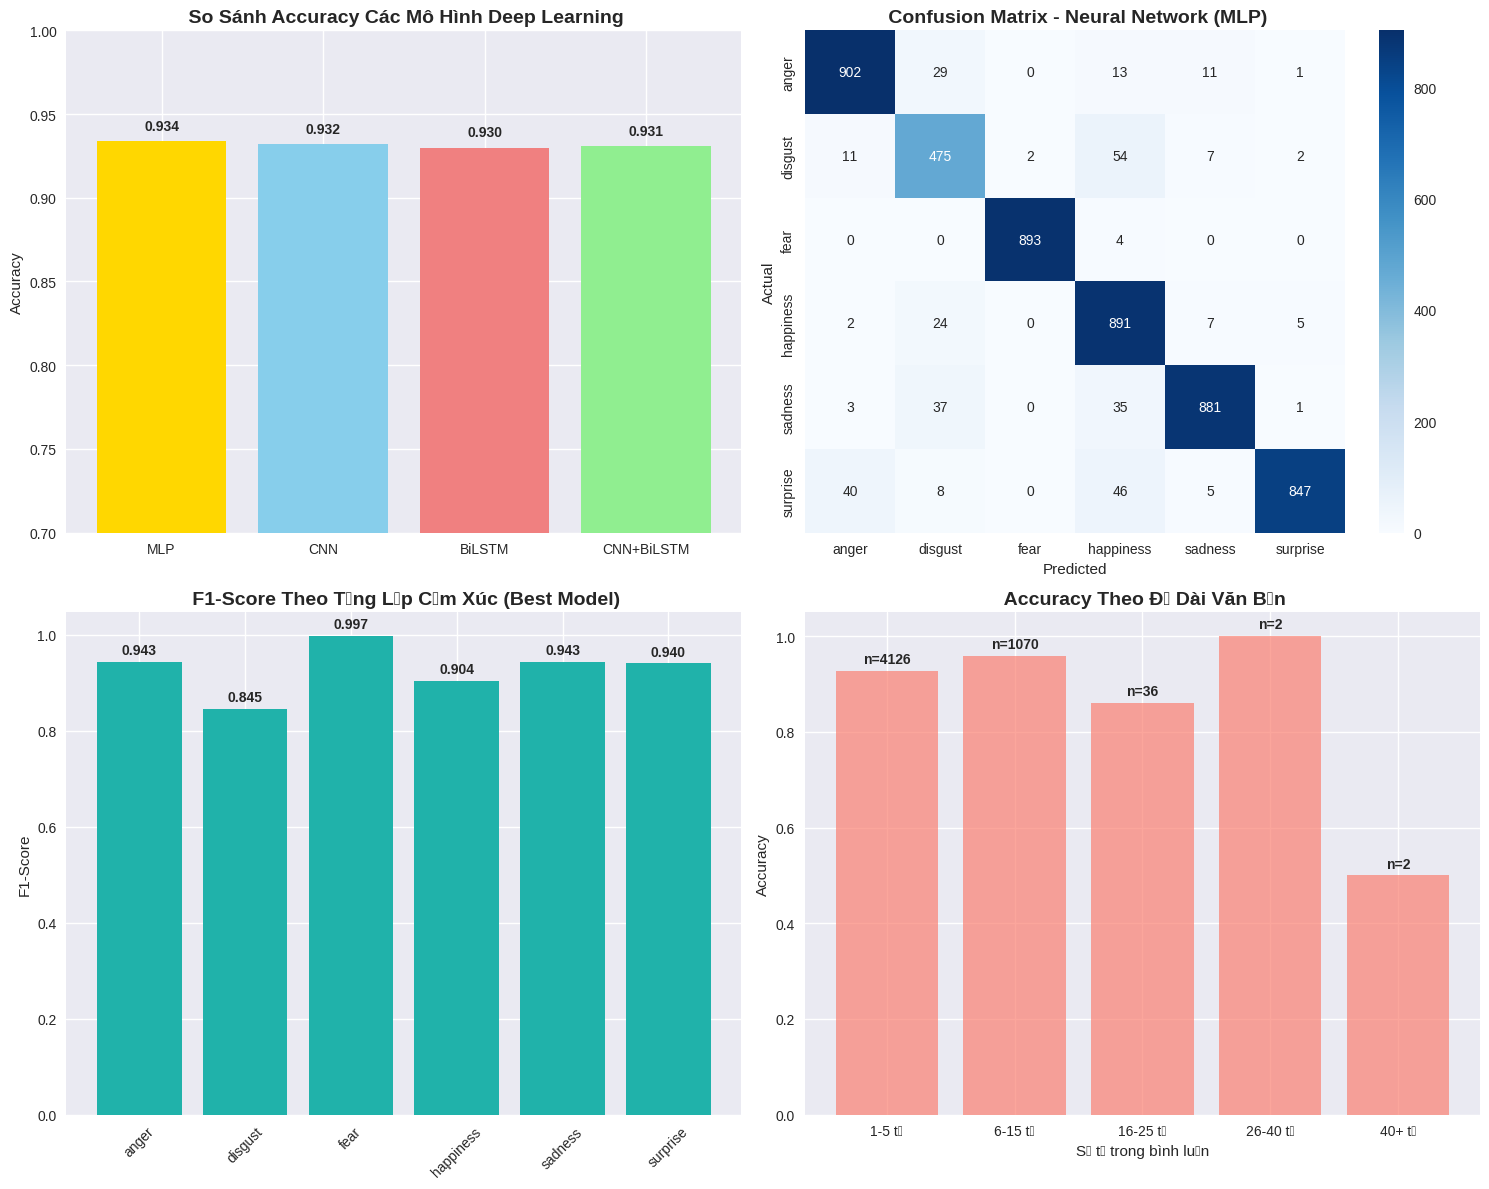


 TÓM TẮT KẾT QUẢ PHÂN TÍCH CẢM XÚC (Deep Learning)
 Dataset: 26,382 mẫu với 6 lớp cảm xúc
 Mô hình tốt nhất: Neural Network (MLP)
 Accuracy: 0.9337 (93.37%)
 F1-Score (macro): 0.9286


In [28]:
#  Trực quan hóa kết quả với mô hình Deep Learning tốt nhất
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. So sánh accuracy các mô hình DL
models = ['MLP', 'CNN', 'BiLSTM', 'CNN+BiLSTM']
accuracies = [nn_accuracy, cnn_accuracy, bilstm_accuracy, hybrid_accuracy]
colors = ['gold', 'skyblue', 'lightcoral', 'lightgreen', 'orange']
bars = ax1.bar(models, accuracies, color=colors)
ax1.set_title(' So Sánh Accuracy Các Mô Hình Deep Learning', fontweight='bold', fontsize=14)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.7, 1.0)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Confusion Matrix của mô hình tốt nhất
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, xticklabels=emotions, yticklabels=emotions)
ax2.set_title(f' Confusion Matrix - {best_model_name}', fontweight='bold', fontsize=14)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# 3. F1-Score theo từng lớp cảm xúc (best model)
f1_scores_by_class = [class_report[emotion]['f1-score'] for emotion in emotions]
bars3 = ax3.bar(emotions, f1_scores_by_class, color='lightseagreen')
ax3.set_title(' F1-Score Theo Từng Lớp Cảm Xúc (Best Model)', fontweight='bold', fontsize=14)
ax3.set_ylabel('F1-Score')
ax3.tick_params(axis='x', rotation=45)
for bar, score in zip(bars3, f1_scores_by_class):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Phân tích độ dài văn bản vs accuracy (best model)
results_df['word_count'] = results_df['text'].str.split().str.len()
bins = pd.cut(results_df['word_count'], bins=5, labels=['1-5', '6-15', '16-25', '26-40', '40+'])
accuracy_by_length = results_df.groupby(bins)['correct'].agg(['mean', 'count'])
bars4 = ax4.bar(range(len(accuracy_by_length)), accuracy_by_length['mean'], color='salmon', alpha=0.7)
ax4.set_title(' Accuracy Theo Độ Dài Văn Bản', fontweight='bold', fontsize=14)
ax4.set_ylabel('Accuracy')
ax4.set_xlabel('Số từ trong bình luận')
ax4.set_xticks(range(len(accuracy_by_length)))
ax4.set_xticklabels(['1-5 từ', '6-15 từ', '16-25 từ', '26-40 từ', '40+ từ'])
for i, (bar, count) in enumerate(zip(bars4, accuracy_by_length['count'])):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={int(count)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# In tóm tắt kết quả
print("\n" + "="*80)
print(" TÓM TẮT KẾT QUẢ PHÂN TÍCH CẢM XÚC (Deep Learning)")
print("="*80)
print(f" Dataset: {len(df):,} mẫu với {len(label_encoder.classes_)} lớp cảm xúc")
print(f" Mô hình tốt nhất: {best_model_name}")
print(f" Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f" F1-Score (macro): {np.mean([class_report[e]['f1-score'] for e in emotions]):.4f}")


##  7. Demo Ứng Dụng Thực Tế

Tạo một hàm để dự đoán cảm xúc cho văn bản mới:

In [29]:
#  Hàm dự đoán cảm xúc cho văn bản mới (Deep Learning)
def predict_emotion(text, model_name=best_model_name, label_enc=label_encoder):
    """
    Dự đoán cảm xúc cho một văn bản mới bằng mô hình DL tốt nhất
    Returns: dict với predicted_emotion, confidence, top_predictions, processed_text
    """
    # Tiền xử lý văn bản
    cleaned_text = clean_text(text)
    final_text = remove_stopwords(cleaned_text)

    # Tokenize + pad
    seq = tokenizer.texts_to_sequences([final_text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Chọn model
    if model_name.startswith('Neural Network') or model_name == 'MLP':
        probs = nn_model.predict(pad)[0]
        model_used = 'MLP'
    elif model_name == 'CNN':
        probs = cnn_model.predict(pad)[0]
        model_used = 'CNN'
    elif model_name == 'BiLSTM':
        probs = bilstm_model.predict(pad)[0]
        model_used = 'BiLSTM'
    else:
        probs = hybrid_model.predict(pad)[0]
        model_used = 'CNN+BiLSTM'

    pred_idx = int(np.argmax(probs))
    emotion_name = label_enc.classes_[pred_idx]

    # Top-3
    top_idx = np.argsort(probs)[::-1][:3]
    top_predictions = [(label_enc.classes_[i], float(probs[i])) for i in top_idx]

    return {
        'predicted_emotion': emotion_name,
        'confidence': float(probs[pred_idx]),
        'top_predictions': top_predictions,
        'processed_text': final_text,
        'model_used': model_used
    }

#  Test với một số câu mẫu
test_samples = [
    "Sản phẩm rất tốt, tôi rất hài lòng với chất lượng",
    "Hàng tệ quá, đóng gói không cẩn thận, bị vỡ mất rồi",
    "Giao hàng chậm quá, đặt một tuần rồi mà chưa có hàng",
    "Wao, không ngờ chất lượng lại tốt như vậy",
    "Buồn quá, mong đợi nhiều mà thất vọng",
    "Tại sao lại không có hướng dẫn sử dụng vậy?"
 ]

print(" DEMO DỰ ĐOÁN CẢM XÚC CHO VĂN BẢN MỚI (Deep Learning)")
print("=" * 70)

for i, text in enumerate(test_samples, 1):
    result = predict_emotion(text)
    print(f" Câu {i}: {text}")
    print(f"    Model dùng: {result['model_used']}")
    print(f"    Cảm xúc dự đoán: {result['predicted_emotion'].upper()}")
    print(f"    Độ tin cậy: {result['confidence']:.3f}")
    print(f"    Văn bản sau xử lý: {result['processed_text']}")
    print(f"    Top 3 dự đoán:")
    for emotion, prob in result['top_predictions'][:3]:
        print(f"      - {emotion}: {prob:.3f} ({prob*100:.1f}%)")
    print()

 DEMO DỰ ĐOÁN CẢM XÚC CHO VĂN BẢN MỚI (Deep Learning)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
 Câu 1: Sản phẩm rất tốt, tôi rất hài lòng với chất lượng
    Model dùng: MLP
    Cảm xúc dự đoán: HAPPINESS
    Độ tin cậy: 0.998
    Văn bản sau xử lý: sản_phẩm tốt hài_lòng chất_lượng
    Top 3 dự đoán:
      - happiness: 0.998 (99.8%)
      - anger: 0.001 (0.1%)
      - disgust: 0.000 (0.0%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Câu 2: Hàng tệ quá, đóng gói không cẩn thận, bị vỡ mất rồi
    Model dùng: MLP
    Cảm xúc dự đoán: DISGUST
    Độ tin cậy: 0.938
    Văn bản sau xử lý: hàng tệ đóng_gói không cẩn_thận vỡ mất
    Top 3 dự đoán:
      - disgust: 0.938 (93.8%)
      - anger: 0.041 (4.1%)
      - sadness: 0.017 (1.7%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
 Câu 3: Giao hàng chậm quá, đặt một tuần rồi mà chưa có hàng
    Model dùng: MLP
    Cảm xúc dự đoán: DISGUST
    Độ tin cậy: 0.727
    Văn bản sau xử lý: giao hàng chậm đặt một tuần chưa hàng
    Top 3 dự đoán:
      - disgust: 0.

##  8. Kết Luận và Hướng Phát Triển

###  Tổng kết

- Đã xây dựng pipeline Deep Learning đầy đủ cho phân tích cảm xúc tiếng Việt: EDA → tiền xử lý → Tokenizer/Pad → huấn luyện 4 mô hình DL (MLP, CNN, BiLSTM, CNN+BiLSTM) → so sánh/đánh giá → lưu mô hình.
- Mô hình tốt nhất theo Accuracy trên tập kiểm thử được chọn tự động trong notebook.
- Kết quả trực quan hóa: biểu đồ Accuracy so sánh, F1-score theo từng lớp, ma trận nhầm lẫn của mô hình tốt nhất, và đường học (loss/accuracy) của từng mô hình.

###  So sánh nhanh các mô hình DL

| Mô hình | Đặc điểm | Khi dùng |
|--------|---------|---------|
| MLP (Embedding+Pooling) | Nhanh, gọn | Baseline DL, dữ liệu vừa/nhỏ |
| 1D CNN | Học n-gram tốt | Cấu trúc cụm từ/ngữ cố định |
| BiLSTM | Bắt ngữ cảnh 2 chiều | Câu dài, phụ thuộc ngữ cảnh |
| CNN+BiLSTM | Kết hợp cục bộ + ngữ cảnh | Cân bằng độ chính xác và tốc độ |




In [30]:
#  Lưu mô hình Deep Learning và các component để sử dụng sau
import pickle
import os

os.makedirs('artifacts', exist_ok=True)

# Chọn model theo best_model_name
if best_model_name == 'CNN':
    best_keras_model = cnn_model
    best_pred = y_pred_cnn
    best_probs = y_pred_cnn_prob
elif best_model_name == 'BiLSTM':
    best_keras_model = bilstm_model
    best_pred = y_pred_bilstm
    best_probs = y_pred_bilstm_prob
elif best_model_name == 'CNN+BiLSTM':
    best_keras_model = hybrid_model
    best_pred = y_pred_hybrid
    best_probs = y_pred_hybrid_prob
else:
    # Fallback: dùng hybrid
    best_keras_model = hybrid_model
    best_pred = y_pred_hybrid
    best_probs = y_pred_hybrid_prob

model_path = os.path.join('artifacts', 'sentiment_model_best.keras')
tokenizer_path = os.path.join('artifacts', 'tokenizer.pkl')
label_path = os.path.join('artifacts', 'label_encoder.pkl')
utils_path = os.path.join('artifacts', 'preprocess_utils.pkl')

best_keras_model.save(model_path)
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
with open(label_path, 'wb') as f:
    pickle.dump(label_encoder, f)
with open(utils_path, 'wb') as f:
    pickle.dump({'clean_function': clean_text, 'stopwords_function': remove_stopwords, 'max_len': max_len}, f)

print(" Đã lưu mô hình và các component:")
print(f"  - Keras model: {model_path}")
print(f"  - Tokenizer:   {tokenizer_path}")
print(f"  - LabelEncoder:{label_path}")
print(f"  - Utils:       {utils_path}")

print("\n Hướng dẫn load lại để dự đoán:")
print("""
import pickle, numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model('artifacts/sentiment_model_best.keras')
with open('artifacts/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('artifacts/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('artifacts/preprocess_utils.pkl', 'rb') as f:
    utils = pickle.load(f)

def predict_new_text(text):
    cleaned = utils['clean_function'](text)
    final_text = utils['stopwords_function'](cleaned)
    seq = tokenizer.texts_to_sequences([final_text])
    pad = pad_sequences(seq, maxlen=utils['max_len'], padding='post', truncating='post')
    probs = model.predict(pad)[0]
    pred = int(np.argmax(probs))
    return label_encoder.classes_[pred], float(np.max(probs))
""")

print(f"\n HOÀN THÀNH PHÂN TÍCH CẢM XÚC (Deep Learning)!")
print("=" * 60)
print(f" Tổng số mẫu đã xử lý: {len(df):,}")
print(f" Mô hình tốt nhất: {best_model_name} với accuracy {best_accuracy*100:.2f}%")
print(f" Có thể phân loại {len(label_encoder.classes_)} loại cảm xúc:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"   {i+1}. {emotion.capitalize()}")
print(f"\n Hệ thống DL đã sẵn sàng để triển khai!")
print("=" * 60)

 Đã lưu mô hình và các component:
  - Keras model: artifacts/sentiment_model_best.keras
  - Tokenizer:   artifacts/tokenizer.pkl
  - LabelEncoder:artifacts/label_encoder.pkl
  - Utils:       artifacts/preprocess_utils.pkl

 Hướng dẫn load lại để dự đoán:

import pickle, numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model('artifacts/sentiment_model_best.keras')
with open('artifacts/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('artifacts/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('artifacts/preprocess_utils.pkl', 'rb') as f:
    utils = pickle.load(f)

def predict_new_text(text):
    cleaned = utils['clean_function'](text)
    final_text = utils['stopwords_function'](cleaned)
    seq = tokenizer.texts_to_sequences([final_text])
    pad = pad_sequences(seq, maxlen=utils['max_len'], padding='post', truncating='post')
    probs = model.predic